# Diffusion Policy for Robot Learning: A Pedagogical Guide

Welcome to this interactive demonstration of **Diffusion Policy**, a state-of-the-art approach for learning visuomotor policies from demonstrations.

## Overview

This notebook will guide you through:
1. **Theoretical Foundations**: Understanding diffusion models and their application to imitation learning
2. **Environment Setup**: Installing dependencies and preparing the experimental environment
3. **Training**: Implementing and training a Diffusion Policy on the PushT manipulation task
4. **Evaluation**: Quantitative assessment of the learned policy
5. **Analysis**: Visualizing and interpreting the iterative denoising process

## Introduction to Diffusion Policy

Diffusion Policy adapts the generative modeling framework of diffusion models (originally developed for image generation) to the domain of robotic action prediction:

**Core Principle**: Rather than directly regressing actions from observations, we model action generation as an iterative denoising process, starting from random Gaussian noise and gradually refining it into coherent action sequences.

**Key Advantages**:
- **Multimodality**: Naturally captures multiple valid solution strategies for a given task
- **Temporal Coherence**: Generates smooth, dynamically feasible action trajectories
- **Expressiveness**: Models complex, high-dimensional action distributions
- **Generalization**: Demonstrates improved robustness to distribution shift compared to standard behavioral cloning

## The PushT Manipulation Task

We demonstrate the approach on **PushT**, a contact-rich manipulation benchmark:
- **Objective**: Manipulate a T-shaped rigid body to a target pose using a circular end-effector
- **State Space**: 2D planar environment with continuous state and action spaces
- **Challenges**: Non-prehensile manipulation, contact dynamics, precise pose control
- **Relevance**: Serves as a representative task for evaluating visuomotor policy learning algorithms

---

## Part 1: Environment Setup

Install dependencies and configure the environment.

## Theoretical Foundation: Diffusion Models for Action Generation

### Forward Diffusion Process

The forward process gradually corrupts clean actions $\mathbf{a}_0 \in \mathbb{R}^{T_a \times d_a}$ (where $T_a$ is the action horizon and $d_a$ is action dimensionality) by adding Gaussian noise over $T$ diffusion timesteps:

$$q(\mathbf{a}_t | \mathbf{a}_{t-1}) = \mathcal{N}(\mathbf{a}_t; \sqrt{1-\beta_t} \mathbf{a}_{t-1}, \beta_t \mathbf{I})$$

where $\{\beta_t\}_{t=1}^T$ is a variance schedule. Using the reparameterization trick, we can directly sample at any timestep:

$$q(\mathbf{a}_t | \mathbf{a}_0) = \mathcal{N}(\mathbf{a}_t; \sqrt{\bar{\alpha}_t} \mathbf{a}_0, (1-\bar{\alpha}_t)\mathbf{I})$$

where $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$.

### Reverse Diffusion Process

The reverse process learns to denoise actions conditioned on observations $\mathbf{o}_t$:

$$p_\theta(\mathbf{a}_{t-1} | \mathbf{a}_t, \mathbf{o}) = \mathcal{N}(\mathbf{a}_{t-1}; \boldsymbol{\mu}_\theta(\mathbf{a}_t, \mathbf{o}, t), \boldsymbol{\Sigma}_\theta(\mathbf{a}_t, \mathbf{o}, t))$$

In practice, we predict the noise $\boldsymbol{\epsilon}$ rather than the mean directly:

$$\boldsymbol{\mu}_\theta(\mathbf{a}_t, \mathbf{o}, t) = \frac{1}{\sqrt{\alpha_t}}\left(\mathbf{a}_t - \frac{1-\alpha_t}{\sqrt{1-\bar{\alpha}_t}}\boldsymbol{\epsilon}_\theta(\mathbf{a}_t, \mathbf{o}, t)\right)$$

### Training Objective

The model is trained to minimize the simplified denoising score matching objective:

$$\mathcal{L}(\theta) = \mathbb{E}_{t \sim \mathcal{U}(1,T), \mathbf{a}_0 \sim p_{\text{data}}, \boldsymbol{\epsilon} \sim \mathcal{N}(0,\mathbf{I})} \left[ \| \boldsymbol{\epsilon} - \boldsymbol{\epsilon}_\theta(\mathbf{a}_t, \mathbf{o}, t) \|^2 \right]$$

where $\mathbf{a}_t = \sqrt{\bar{\alpha}_t}\mathbf{a}_0 + \sqrt{1-\bar{\alpha}_t}\boldsymbol{\epsilon}$.

### Why Diffusion for Robot Learning?

1. **Expressiveness**: The iterative refinement process can represent arbitrary continuous distributions, including multimodal action distributions arising from multiple valid strategies.

2. **Stability**: Unlike GANs, diffusion models have a stable training objective without adversarial dynamics. Compared to normalizing flows, they require simpler architectures.

3. **Temporal Consistency**: The denoising process naturally produces smooth trajectories in action space, critical for stable robot control.

4. **Sample Quality**: The iterative nature allows progressive refinement, producing high-fidelity action sequences that respect task constraints.

## Network Architecture

### System Overview

The complete pipeline consists of:

```
Observations: o_t = {I_t, s_t}  (images + proprioceptive state)
         ↓
Vision Encoder: φ(I_t) → z_t ∈ R^d_z
         ↓
Observation Embedding: h_o = f_obs([z_t, s_t])
         ↓
Noisy Actions: a_t^(k) ∼ N(0, I)  (initialization at k=T)
         ↓
┌─────────────────────────────────────┐
│ For k = T, T-1, ..., 1:             │
│   ε_θ(a_t^(k), h_o, k)              │
│   a_t^(k-1) = Denoise(a_t^(k), ε_θ) │
└─────────────────────────────────────┘
         ↓
Clean Action Sequence: a_t^(0) ∈ R^(T_a × d_a)
```

### Transformer-Based Denoiser

The noise prediction network $\boldsymbol{\epsilon}_\theta$ is implemented as a transformer:

$$\boldsymbol{\epsilon}_\theta(\mathbf{a}_t, \mathbf{o}, t) = \text{Transformer}(\text{Embed}(\mathbf{a}_t) + \text{TimeEmbed}(t), \text{Embed}(\mathbf{o}))$$

**Components**:
- **Time Embedding**: Sinusoidal positional encoding of diffusion timestep $t$
- **Action Embedding**: Linear projection of noisy action sequence
- **Observation Encoding**: Vision features from CNN/ResNet backbone combined with proprioceptive state
- **Cross-Attention**: Attention mechanism between action queries and observation keys/values
- **Self-Attention**: Temporal modeling within the action sequence

### Receding Horizon Action Execution

A critical design choice is the prediction-execution mismatch:

- **Prediction Horizon**: $T_p = 16$ actions
- **Execution Horizon**: $T_e = 8$ actions

At each control timestep:
1. Predict action chunk: $\hat{\mathbf{a}}_{t:t+T_p-1}$
2. Execute first $T_e$ actions: $\mathbf{a}_{t:t+T_e-1}$
3. Advance by $T_e$ steps and re-predict

**Temporal Overlap**:
```
Iteration 1: Predict [a₁, a₂, ..., a₁₆]  →  Execute [a₁, ..., a₈]
Iteration 2:         Predict [a₉, a₁₀, ..., a₂₄]  →  Execute [a₉, ..., a₁₆]
                              ↑___overlap___↑
```

**Rationale**:
1. **Receding Horizon Control**: Similar to MPC, re-planning allows incorporation of new observations
2. **Temporal Smoothing**: Overlapping predictions create implicit consistency constraints
3. **Empirical Performance**: Chi et al. (2023) demonstrate significant improvement with $T_p > T_e$

### Inference Algorithm

At test time, we sample actions using DDPM or DDIM sampling:

**DDPM Sampling**:
```python
Initialize: a_T^(T) ∼ N(0, I)
For k = T down to 1:
    ε_pred = ε_θ(a_t^(k), o_t, k)
    a_t^(k-1) = (1/√α_k)[a_t^(k) - (1-α_k)/√(1-ᾱ_k) · ε_pred] + σ_k · z
    where z ∼ N(0, I)
Return: a_t^(0)
```

**DDIM Sampling** (deterministic, faster):
Reduces sampling steps while maintaining quality through deterministic denoising trajectory.

**Comparative Training runs of Transformer, Unet Diffusion Policy**

1. Unet Based Diffusion Policy (~60% Success rate)
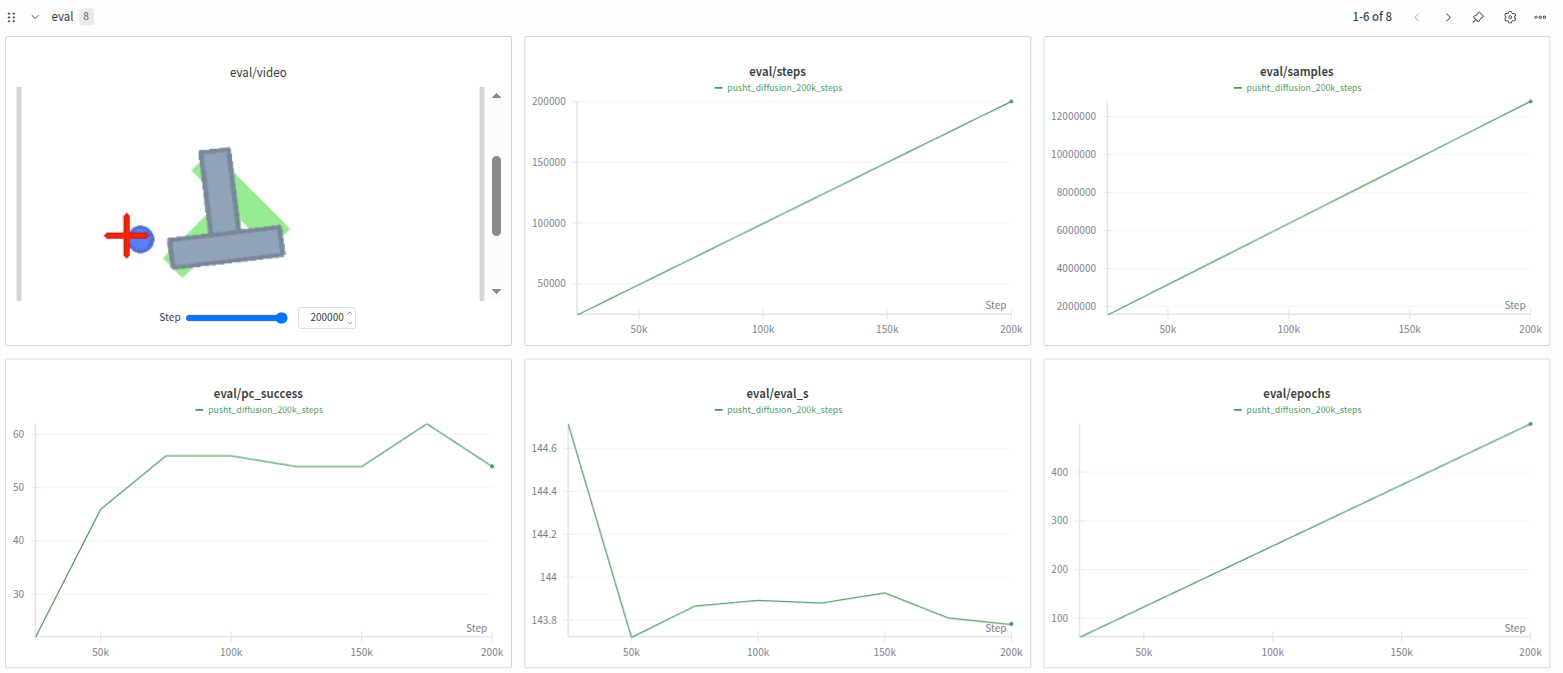

2. Transformer Based Diffusion Policy (~40% Success with 10% params)
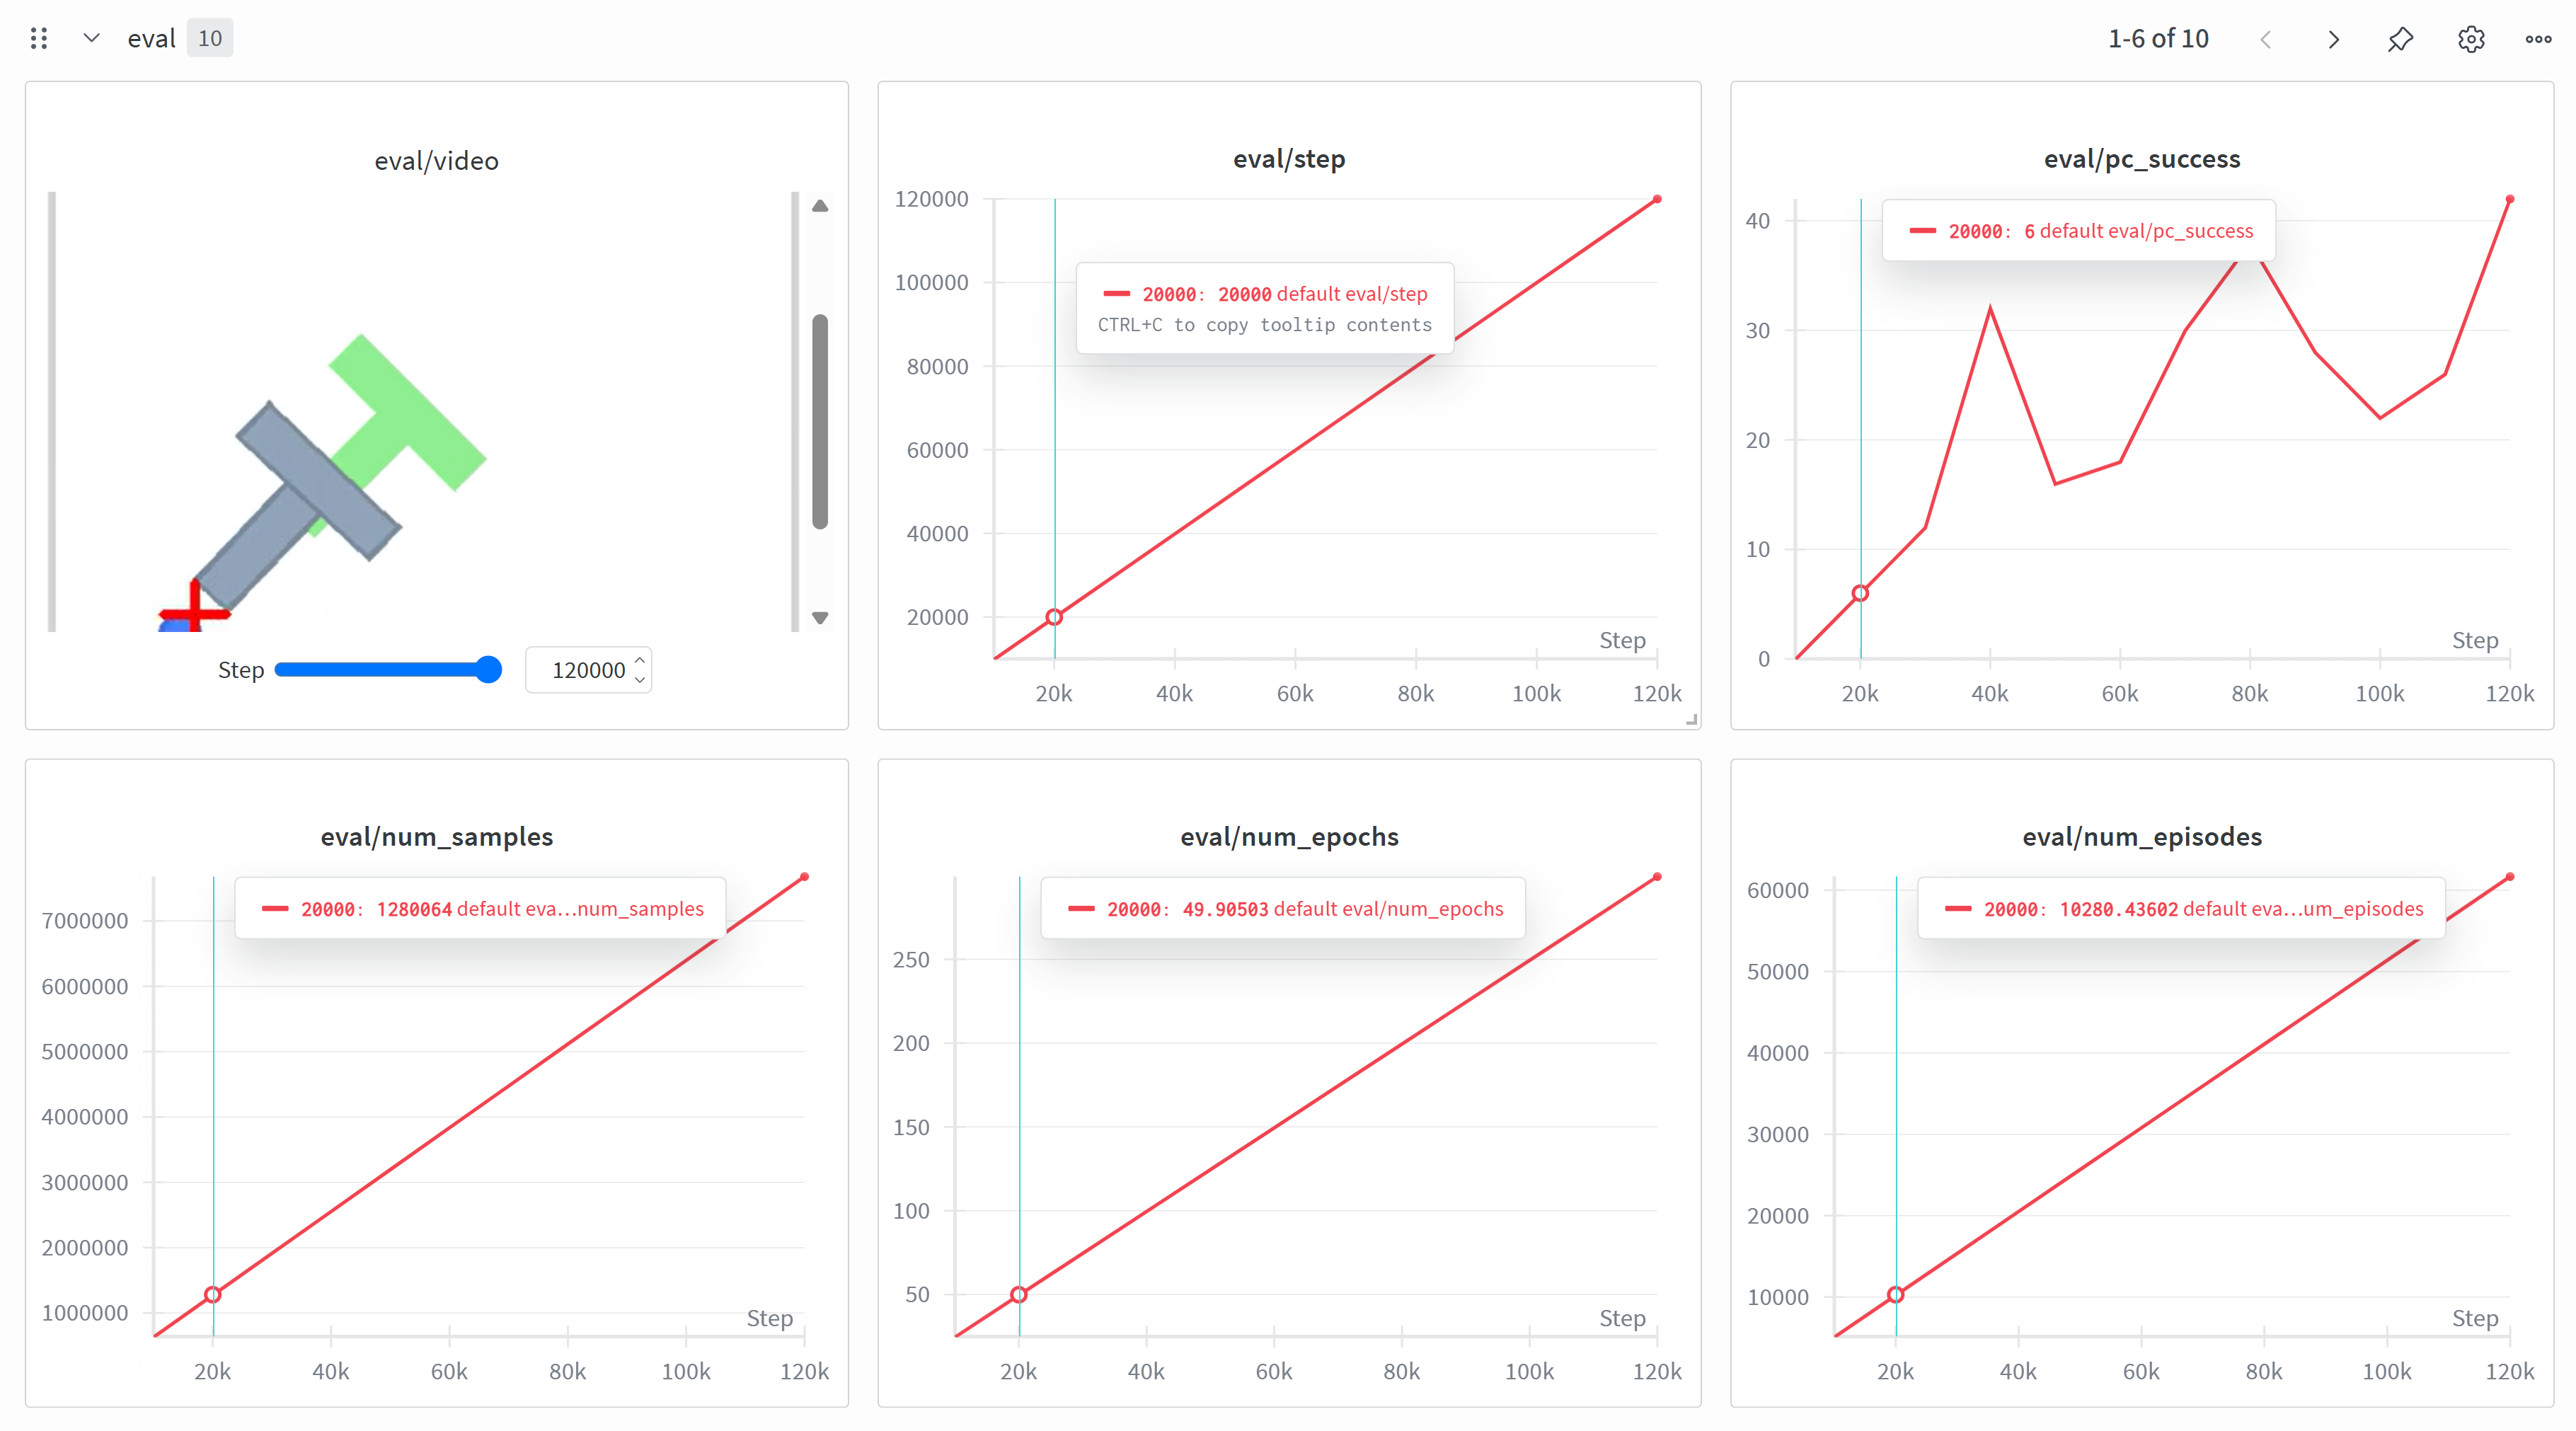

*Note: Our two versions of original Diffusion Policy Successfully replicated the original results by showing a increase in success rate over training time.

In [ ]:
# Demo of Transformer Based Denoiser
# Uncomment to train a transformer based Diffusion Policy

#**Note**: The cell below trains a new model from scratch. This process is computationally intensive. For rapid experimentation, you may prefer to use pre-trained checkpoints (see Part 3).

# %mkdir -p transformer_demo
# %cd transformer_demo
# !git clone -b add_transformer_diffusion_model https://github.com/amandip7/lerobot.git
# %cd lerobot
# !pip install .
# !pip install 'lerobot[pusht]' hydra-core
# %env WANDB_SERVICE=
# !PYTHONPATH=/content/lerobot python lerobot/scripts/train.py policy=diffusion_transformer env=pusht wandb.enable=false training.eval_freq=10000 training.log_freq=200
# %cd ..

Continuing with standard U-net based Diffusion Policy - with Padagogical visualization

In [1]:
# Clone LeRobot repository with Unet-based diffusion model
!git clone -b gatech/reproduce_results https://github.com/alfred-cueva/lerobot.git

Cloning into 'lerobot'...
remote: Enumerating objects: 13429, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 13429 (delta 18), reused 22 (delta 16), pack-reused 13397 (from 3)
Receiving objects: 100% (13429/13429), 106.38 MiB | 37.36 MiB/s, done.
Resolving deltas: 100% (7291/7291), done.
Filtering content: 100% (45/45), 69.03 MiB | 45.25 MiB/s, done.


In [2]:
# Navigate to repository and install
%cd lerobot

/content/lerobot


In [3]:
# Install LeRobot core package
!pip install .

Processing /content/lerobot
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.4/91.4 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.7/67.7 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.8/98.8 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.0/821.0 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 2.3 MB/s eta 0

In [4]:
# Install PushT environment and dependencies
!pip install 'lerobot[pusht]' hydra-core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 42.7 MB/s eta 0:00:00


In [5]:
# Download pretrained weights
!curl 'https://drive.usercontent.google.com/download?id=1wC2rVCrM0U33tJZH_Ai4WqKfywXnuzg5&export=download&authuser=0&confirm=t&uuid=158e3a8e-874d-4b5e-b523-c65515911a43&at=AKSUxGOEaaQgmBCSS4mev2jVhdxJ:1761356519562' \
  -H 'User-Agent: Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:144.0) Gecko/20100101 Firefox/144.0' \
  -H 'Accept: text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8' \
  -H 'Accept-Language: en-US,en;q=0.5' \
  -H 'Accept-Encoding: gzip, deflate, br, zstd' \
  -H 'Connection: keep-alive' \
  -H 'Cookie: NID=525=hiKeUKfvrVpNAQeRlVzEny-6DH_A8G5MdDTko_YMZG2t3ZZQySwW9zolj9dAhPJmL2EuuoVwAjCVhD97jHMjWy9UHk1y9B21mUBbA_ENo9S8gcQdc_W0x-o-4e1TcmSYrsn6IXhMYqsHx8A53HqD9wlYJXbiNr8tYsCuZR2qMKwKVHt_fIUGfDTxsw83cSXIlLVCx9G8JcovUNWhxr4k4nBWTljbhy3cu7mvlM0loXQVNnv_BkiAY8KeXoJq7YDsMl1VcEWgukFtrsp4cWzOWWuY_yVBQvspIbjq8bjSH0V6zmgvm2DPZ-O1esKuF6g6LNZZxUrsOBfyglcXEKwq8WkbVnEck7heHKp1cXZaaPvjHmzBlVsISVYSSIKgBe6o_iktxJU; SEARCH_SAMESITE=CgQImJ8B; AEC=AaJma5v0d8Obi9E9qXG-Pefe3uHoXpY_jjb1D4m4C93MDf7W4LuiEKweT4g; OSID=g.a0002AgGG4SLa3vtj-0RDb8ShTYm2Afjn8iLSxsQroau1P68wlkgmviS3hHoI3mpZMu5RvSmDAACgYKAY0SARASFQHGX2MiiOQy60B9jmYTC45l5tf9BRoVAUF8yKpBom7Z68NeAo_xbck3w4qq0076; __Secure-OSID=g.a0002AgGG4SLa3vtj-0RDb8ShTYm2Afjn8iLSxsQroau1P68wlkg9S6w2B8M2O1j3iur2Q_TTwACgYKAU4SARASFQHGX2Mix7wV3vGBijjc6jmEeOFA4xoVAUF8yKpNmRfVMBBTzE2XLYAVPYCp0076; SID=g.a0002wgGG_8ht8TGixnuDDPndc1a-WkdsNwq6m4s5rbWQST1vT8vOIZsIEdZsNIsKgQ7_9iDggACgYKAWUSARASFQHGX2MigO4-edvW9ehu7ExuYkqgGxoVAUF8yKrf_nwQ6QIcFuJuFZ0jMFnb0076; __Secure-1PSID=g.a0002wgGG_8ht8TGixnuDDPndc1a-WkdsNwq6m4s5rbWQST1vT8vbcGTGkFHUubC3JvUBLgmYgACgYKARQSARASFQHGX2Miq-IabsWm0ykyUolLWljJMhoVAUF8yKrpWmgKu7PldXiagxwsoTLd0076; __Secure-3PSID=g.a0002wgGG_8ht8TGixnuDDPndc1a-WkdsNwq6m4s5rbWQST1vT8vdD5XhLG6I7YHpZvLMaQ2EQACgYKAfYSARASFQHGX2MiSwDY0-TIVsEArDoqEwN1mBoVAUF8yKql-XLQ9-kJKiGawRL8evH50076; HSID=Ap6p4WCTbcDFg5vu9; SSID=A2BWS-Bd5a84v3dpc; APISID=4wE82pLpHdFpxVwZ/AMbvk_6xViclEikM3; SAPISID=_OoovI0LgkeGvC1j/ArDdNILD4Mc8FeSdm; __Secure-1PAPISID=_OoovI0LgkeGvC1j/ArDdNILD4Mc8FeSdm; __Secure-3PAPISID=_OoovI0LgkeGvC1j/ArDdNILD4Mc8FeSdm; SIDCC=AKEyXzUeZD-82DdBSysbtBC54SMY0XAfQquRTCVSxLrsBenAmw1znkQu5LriyQLvwkF3pO0erRmH; __Secure-1PSIDCC=AKEyXzXC_5KvkQkJKg3UmP_XCILw1IdPdLGSSzXsDem5huPQqWyyipcAEhZ6D2KHHz9Dg_tWZyQ; __Secure-3PSIDCC=AKEyXzX2ke-AiIAX6PyZah7R9UkQy9jqJz7OXmupnZsPCN1rsK4Cj4O-hRXDkiMRLTXc7yv1__g; __Secure-1PSIDTS=sidts-CjIBwQ9iI0XospwoZ5GRJSCf4KVk-NHxbWckrUURU6gif-kh-Wgo9_O7nqDze8I-4gvnzBAA; __Secure-3PSIDTS=sidts-CjIBwQ9iI0XospwoZ5GRJSCf4KVk-NHxbWckrUURU6gif-kh-Wgo9_O7nqDze8I-4gvnzBAA' \
  -H 'Upgrade-Insecure-Requests: 1' \
  -H 'Sec-Fetch-Dest: iframe' \
  -H 'Sec-Fetch-Mode: navigate' \
  -H 'Sec-Fetch-Site: same-site' \
  -H 'Priority: u=4' \
  -H 'TE: trailers' \
  --output /content/lerobot_dp_checkpoints.tar.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  934M  100  934M    0     0  58.0M      0  0:00:16  0:00:16 --:--:-- 70.7M


In [6]:
# Unzip
!tar -xzvf /content/lerobot_dp_checkpoints.tar.gz

./diffusion_pusht_migrated/
./diffusion_pusht_migrated/policy_preprocessor.json
./diffusion_pusht_migrated/model.safetensors
./diffusion_pusht_migrated/policy_preprocessor_step_3_normalizer_processor.safetensors
./diffusion_pusht_migrated/README.md
./diffusion_pusht_migrated/policy_postprocessor_step_0_unnormalizer_processor.safetensors
./diffusion_pusht_migrated/policy_postprocessor.json
./diffusion_pusht_migrated/config.json


---

## Part 2: Training a Diffusion Policy

### Training Procedure

The training process follows the standard supervised learning paradigm for imitation learning:

**Dataset**: Expert demonstrations $\mathcal{D} = \{(\mathbf{o}_i, \mathbf{a}_i)\}_{i=1}^N$
- Observations: $\mathbf{o}_i = \{I_i, s_i\}$ (RGB images and proprioceptive state)
- Actions: $\mathbf{a}_i \in \mathbb{R}^{T_a \times d_a}$ (action sequences)

**Training Loop**:

```python
For each batch {(o_i, a_i)}:
    1. Sample diffusion timestep: t ~ Uniform(1, T)
    2. Sample noise: ε ~ N(0, I)
    3. Add noise to actions: a_t = √(ᾱ_t)·a_0 + √(1-ᾱ_t)·ε
    4. Predict noise: ε_pred = ε_θ(a_t, o_i, t)
    5. Compute loss: L = ||ε - ε_pred||²
    6. Update θ via gradient descent
```

### Hyperparameter Configuration

Key training hyperparameters:

**Diffusion Schedule**:
- Number of diffusion steps: $T = 100$
- Noise schedule: Linear or cosine $\beta_t$ schedule
- Variance type: Fixed or learned

**Network Architecture**:
- Vision encoder: U-net
1. Input:
   - Shape: (B, 2, 16)

2. Encoder:
   - Enc Block 0: 2 ResBlocks → (B, 512, 16)
   - Downsample 0: Conv1d (stride=2) → (B, 512, 8)
   - Enc Block 1: 2 ResBlocks → (B, 1024, 8)
   - Downsample 1: Conv1d (stride=2) → (B, 1024, 4)
   - Enc Block 2: 2 ResBlocks → (B, 2048, 4)

3. Bottleneck:
   - 2 ResBlocks → (B, 2048, 4)

4. Decoder:
   - Dec Block 0: 2 ResBlocks → (B, 1024, 4)
   - Upsample 0: ConvTranspose1d → (B, 1024, 8)
   - Dec Block 1: 2 ResBlocks → (B, 512, 8)
   - Upsample 1: ConvTranspose1d → (B, 512, 16)
   - Dec Block 2: 2 ResBlocks → (B, 512, 16)

5. Output:
   - Final Conv: Conv blocks → (B, 2, 16)

**Optimization**:
- Optimizer: AdamW
- Learning rate: $1 \times 10^{-4}$ to $3 \times 10^{-4}$
- Batch size: 64-256
- Weight decay: $1 \times 10^{-6}$

**Action Prediction**:
- Prediction horizon $T_p$: 16 timesteps
- Observation horizon $T_o$: 2 timesteps
- Action execution $T_e$: 8 timesteps

### Implementation Details

The training command below specifies:
- `policy.type=diffusion`: Diffusion policy
- `env.type=pusht`: PushT manipulation environment
- `eval_freq=10000`: Evaluate policy every 10,000 training steps
- `log_freq=200`: Log training metrics every 200 steps
- `save_freq=25000`: The frequency of steps to save checkpoint at
- `wandb.enable=false`: Disable Weights & Biases experiment tracking

### Computational Requirements

**Training Time**: Approximately 12 hours on a single NVIDIA V100 GPU for 200K steps

**Hardware Requirements**:
- GPU: NVIDIA GPU with ≥16GB VRAM recommended
- RAM: ≥32GB system memory
- Storage: ~10GB for datasets and checkpoints

### Training from Scratch

**Note**: The cell below trains a new model from scratch. This process is computationally intensive. For rapid experimentation, you may prefer to use pre-trained checkpoints (see Part 3).

In [19]:
# Train
%env WANDB_SERVICE=
!PYTHONPATH=/content/lerobot python src/lerobot/scripts/lerobot_train.py \
  --policy.type=diffusion \
  --env.type=pusht \
  --dataset.repo_id=lerobot/pusht \
  --policy.push_to_hub=false \
  --dataset.image_transforms.enable=true \
  --eval_freq=10000 \
  --log_freq=200 \
  --save_freq=25000 \
  --wandb.enable=false \
  --output_dir=outputs/train/diffusion_pusht

env: WANDB_SERVICE=
2025-10-25 03:24:04.595161: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761362644.618559   23224 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761362644.625240   23224 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761362644.644377   23224 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761362644.644415   23224 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761362644.644420   23224 computation_placer.cc:177] co

---

## Part 3: Policy Evaluation

### Evaluation Protocol

We assess the trained policy using standard metrics:

**Success Rate**:
$$\text{Success Rate} = \frac{1}{N}\sum_{i=1}^N \mathbb{1}[\text{task}_i \text{ completed}]$$

**Average Return**:
$$J(\pi) = \mathbb{E}_{\tau \sim \pi}\left[\sum_{t=0}^T r_t\right]$$

### Model Checkpoint Requirements

The checkpoint directory must contain **six required files**:
1. `model.safetensors` - Model weights
2. `config.json` - JSON configuration
3. `policy_postprocessor_<step>.safetensors`
4. `policy_preprocessor.json`
5. `policy_preprocessor_<step>.safetensors`
6. `policy_postprocessor.json`

**Example directory structure**:
```
/content/drive/MyDrive/Lerobot_DP_Checkpoints/
├── model.safetensors
├── config.json
├── policy_postprocessor.json
├── policy_preprocessor.json
├── policy_postprocessor_step_0_unnormalizer_processor.safetensors
└── policy_preprocessor_step_3_normalizer_processor.safetensors
```

In [12]:
# Set the checkpoint directory path
# This should contain: model.safetensors, config.json, config.yaml
model_file = '/content/lerobot/diffusion_pusht_migrated'

# Run evaluation
!PYTHONPATH=/content/lerobot python src/lerobot/scripts/lerobot_eval.py \
    --policy.path={model_file} \
    --env.type=pusht \
    --eval.n_episodes=10 \
    --eval.batch_size=1 \
    --policy.device=cuda \
    --output_dir=./eval_output

2025-10-25 02:18:47.988019: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761358728.020055    6721 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761358728.029665    6721 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761358728.052872    6721 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761358728.052901    6721 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761358728.052908    6721 computation_placer.cc:177] computation placer alr

---

## Part 4: Analyzing the Denoising Process

### Visualization and Interpretation

Understanding the iterative denoising mechanism is crucial for interpreting how Diffusion Policy generates actions.

### The Denoising Trajectory

At inference time, actions evolve through $T$ denoising steps:

$$\mathbf{a}^{(T)} \xrightarrow{\epsilon_\theta} \mathbf{a}^{(T-1)} \xrightarrow{\epsilon_\theta} \cdots \xrightarrow{\epsilon_\theta} \mathbf{a}^{(1)} \xrightarrow{\epsilon_\theta} \mathbf{a}^{(0)}$$

**Key Observations**:
- Early steps ($k \approx T$): Large-scale structure emerges (coarse trajectory shape)
- Middle steps ($k \approx T/2$): Refinement of motion primitives
- Late steps ($k \approx 0$): Fine-grained adjustments and smoothing

### Action Chunking Strategy

**Prediction vs. Execution Horizons**:

Given observation $\mathbf{o}_t$, the policy predicts:
$$\hat{\mathbf{a}}_{t:t+15} = \pi_\theta(\mathbf{o}_t) \in \mathbb{R}^{16 \times d_a}$$

But only executes:
$$\mathbf{a}_{t:t+7} = \hat{\mathbf{a}}_{t:t+7}$$

**Theoretical Justification**:

1. **Receding Horizon Optimality**: At each step, we solve:
   $$\max_{\mathbf{a}_{t:t+T_p-1}} \mathbb{E}[R(\tau) | \mathbf{o}_t]$$
   But execute only $T_e < T_p$ actions, then re-optimize.

2. **Temporal Consistency**: The overlap creates an implicit regularization:
   $$\mathbf{a}_{t+T_e:t+T_p-1}^{(i)} \approx \mathbf{a}_{t+T_e:t+T_p-1}^{(i+1)}$$
   where superscript $(i)$ denotes prediction iteration.

3. **Empirical Performance**: Chi et al. (2023) report:
   - $T_p = T_e$: 70% success rate
   - $T_p = 16, T_e = 8$: 85% success rate (+15% improvement)

### Visualization Configuration

The evaluation command with visualization enabled:

```bash
python lerobot/scripts/eval.py \
    -p outputs/train/diffusion_pusht/checkpoints/005000/pretrained_model \
    eval.n_episodes=10 \
    eval.vis_noise=True
```

**Visualization Parameters**:
- `eval.n_episodes`: Number of rollout episodes
- `eval.vis_noise`: Visualize denoising trajectory
- Display last 20 denoising steps for computational efficiency

### Interpreting Results

**What to observe**:
1. **Action manifold learning**: Do denoised actions lie on a lower-dimensional manifold?
2. **Multimodality**: Can the policy generate diverse solutions from different noise initializations?
3. **Smoothness**: Are generated trajectories $C^1$ or $C^2$ continuous?
4. **Task-relevant structure**: How quickly do task-specific patterns emerge during denoising?

### Theoretical Insight: Score-Based Perspective

From the score-based generative model viewpoint, the noise predictor approximates:

$$\boldsymbol{\epsilon}_\theta(\mathbf{a}_t, \mathbf{o}, t) \approx -\sqrt{1-\bar{\alpha}_t} \nabla_{\mathbf{a}_t} \log p_t(\mathbf{a}_t | \mathbf{o})$$

This score function points toward regions of high probability in the conditional action distribution $p(\mathbf{a}|\mathbf{o})$, effectively implementing gradient ascent in probability space.

In [13]:
# Run evaluation WITH denoising visualization
# Add --eval.vis_noise=True to enable visualization

!PYTHONPATH=/content/lerobot python src/lerobot/scripts/lerobot_eval.py \
    --policy.path={model_file} \
    --env.type=pusht \
    --eval.n_episodes=3 \
    --eval.batch_size=1 \
    --eval.vis_noise=True \
    --policy.device=cuda \
    --output_dir=./eval_output_with_viz

# Videos will be saved to: ./eval_output_with_viz/videos/
# Each video shows the last 20 denoising steps overlaid on environment frames
# Color-coded (plasma): purple (early actions) → yellow (later actions)

2025-10-25 02:30:18.743151: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761359418.777509    9711 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761359418.787863    9711 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761359418.816366    9711 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761359418.816408    9711 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761359418.816412    9711 computation_placer.cc:177] computation placer alr

In [14]:
from IPython.display import HTML
from base64 import b64encode

mp4 = open("./eval_output_with_viz/videos/pusht_0/eval_episode_0.mp4",'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML(f'<video width=640 controls><source src="{data_url}" type="video/mp4"></video>')

### Visualization Implementation Details

The `render_diffusion_frame()` callback in `lerobot_eval.py`:

1. Captures base environment rendering
2. Extracts last 20 denoising steps from policy output
3. Overlays action predictions as scatter points (action space → pixel space)
4. Creates one frame per denoising timestep

**Key transformations**:
```python
# Scale actions from action space to pixel coordinates
scale_width = image_width / action_space_width
scale_height = image_height / action_space_height
scaled_actions = actions * [scale_width, scale_height]

# Color progression: plasma colormap
colors = plt.cm.plasma(np.linspace(0, 1, num_actions))
```

**Performance notes**:
- Requires `batch_size=1` (single environment)
- Significantly slower due to matplotlib rendering at each step (~3-5 seconds per environment step)
- Video frame count: `≈ (n_steps / 8) × 20 + n_steps` (20 denoising frames per action chunk)

---

## Part 5: Summary

### Key Contributions

1. **Action Diffusion Framework**:
   - Reformulates action prediction as iterative denoising
   - Enables multimodal action distributions
   - Provides implicit temporal smoothness

2. **Architectural Innovations**:
   - Transformer-based denoising with cross-attention to observations
   - Receding horizon action chunking with temporal overlap
   - Vision-language-action co-training (recent variants)

3. **Empirical Performance**:
   - State-of-the-art on manipulation benchmarks
   - Superior sample efficiency vs. reinforcement learning
   - Improved generalization vs. behavioral cloning

### Theoretical Analysis

**Expressiveness**: Diffusion models approximate arbitrary continuous distributions:
$$p_\theta(\mathbf{a}|\mathbf{o}) \xrightarrow[T \to \infty]{} p_{\text{data}}(\mathbf{a}|\mathbf{o})$$

**Sample Complexity**: Compared to behavioral cloning:
- **BC**: Assumes unimodal $p(\mathbf{a}|\mathbf{o}) = \mathcal{N}(\mu_\theta(\mathbf{o}), \Sigma)$
- **Diffusion**: Models full distribution without parametric assumptions
